In [1]:
%%writefile .env.example
VK_TOKEN=YOUR_VK_API_TOKEN_HERE

Overwriting .env.example


In [2]:
import json
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()

# Настройки подключения
TOKEN = os.getenv("VK_TOKEN") # api-ключ
VERSION = "5.131"
DOMAIN = "brstu"  # Короткое имя паблика vk.com/brstu
TOTAL_POSTS_TO_PARSE = 100  # количество постов в выборке

# функция парсинга по домену domain постов в количестве total_count
def parse_vk_wall(domain, total_count):
    dataset = []
    offset = 0

    while len(dataset) < total_count:
        url = "https://api.vk.com/method/wall.get"
        params = {
            "access_token": TOKEN,
            "v": VERSION,
            "domain": domain,
            "count": 100,
            "offset": offset,
        }

        response = requests.get(url, params=params).json()

        if "error" in response:
            print(f"Ошибка API: {response['error']['error_msg']}")
            break

        posts = response["response"]["items"]
        if not posts:
            break  # Если посты закончились раньше времени

        for post in posts:
            
            if len(dataset) >= total_count:
                break
            post_text = post.get("text", "")  # текст поста
            # Считаем длину текста (если текста нет, будет 0)
            text_length = len(post.get("text", ""))
            if text_length == 0:
                continue

            # запрашиваемые данные
            post_data = {
                "owner_id": post["owner_id"],
                "id": post["id"],
                "Дата": post["date"],  # Unix timestamp (секунды)
                "Текст_поста": post_text,
                "Длина_текста": text_length,
                "Количество лайков": post.get("likes", {}).get("count", 0),
                "Количество комментариев": post.get("comments", {}).get("count", 0),
                "Количество репостов": post.get("reposts", {}).get("count", 0),
                "Количество просмотров": post.get("views", {}).get("count", 0)
            }
            dataset.append(post_data)
        print(f"Собрано постов: {len(dataset)}")
        offset += len(posts)
        time.sleep(0.4)

    return dataset


# Запуск парсинга
data = parse_vk_wall(DOMAIN, TOTAL_POSTS_TO_PARSE)

# Сохранение в JSON-файл
with open("brstu_data.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

print("Данные успешно сохранены в файл brstu_data.json")

Собрано постов: 94
Собрано постов: 100
Данные успешно сохранены в файл brstu_data.json


In [3]:
df = pd.read_json("brstu_data.json")
print("Исходные данные:")
df

Исходные данные:


,owner_id,id,Дата,Текст_поста,Длина_текста,Количество лайков,Количество комментариев,Количество репостов,Количество просмотров
0,-2220502,25923,1782372600,👨‍🎓18–19 июня на Гуманитарно-педагогическом фа...,1849,14,0,1,610
1,-2220502,25922,1782369000,Продолжается прием заявок на Всероссийский кон...,1689,5,0,0,475
2,-2220502,25921,1782365400,24 июня в ТКЦ «Братск-Арт» прошла встреча с мэ...,240,27,0,1,909
3,-2220502,25920,1782358200,⚡️На факультете энергетики и автоматики успешн...,2000,45,0,3,2706
4,-2220502,25919,1782354608,Для обучающихся базовой кафедры воспроизводств...,853,20,0,1,988
...,...,...,...,...,...,...,...,...,...
95,-159042164,468,1780205806,Всемирный день без табака ежегодно отмечается ...,2005,15,0,0,546
96,-2220502,25731,1780194387,"Уважаемые коллеги - работники кафедры ЭБЖиФ, и...",794,38,0,1,1283
97,-2220502,25728,1780039860,"♻️В Братске прошел фестиваль юннатских клубов,...",1255,35,0,0,1521
98,-2220502,25727,1780036200,Научно-образовательный центр мехатроники и роб...,640,26,0,3,1362


In [4]:
# Чтение сырого JSON
df = pd.read_json("brstu_data.json")

# Переименование столбцов
rename_rules = {
    "Дата": "date",
    "Длина_текста": "text_length",
    "Количество лайков": "likes",
    "Количество комментариев": "comments",
    "Количество репостов": "reposts",
    "Количество просмотров": "views",
    "Текст_поста": "text",
}
df = df.rename(columns=rename_rules)

# Темы постов
THEMES = {
    "Наука": ["научн", "конференц", "стать", "грант", "исследован", "публикац", "вкр", "диплом", "защит", "антиплагиат", "руководител"],
    "Приемная комиссия": ["абитуриент", "поступл", "приемн", "комисси", "егэ", "олимпиад", "бакалавр", "магистр", "направлен", "факультет", "институт"],
    "Культура": ["студвесна", "концерт", "фестиваль", "актив", "волонтер", "доброволец", "творчеств", "сцена", "праздник", "дк", "мисс", "мистер", "заявк", "проект",
                "патриот", "солдат", "геро", "воин", "памят", "велик", "отечествен", "мемориал", "караул", "защитник", "росси", "родин", "отчизн", "подвиг", "возложен", "цвет", "флаг", "гимн", "герб", "чест", "историч", "почтил"],
    "Учеба": ["практик","лабораторн","лекци","курсов","заняти","пара","расписани","студент", "сесси", "экзамен", "зачет", "пересдач", "долг", "ведомост"],
    "Стипендия и карьера": ["стипенди", "выплат", "повышенн", "социальн", "материалк", "карьера", "вакансия", "работа", "зарплата", "рабочий", "профессия", "специалист",
                            "специальность", "кадр", "собеседование", "обучение", "резюме", "трудоустройство", "практика", "бищнес", "рынок", "рынк", "Эн+"],
    "Спорт": ["спорт", "матч", "соревнован", "сборн", "турнир", "чемпионат"],
    "Безопасность": ["мошенник", "схема", "безопасность", "обман", "пароль", "взлом", "осторожно", "данные"],

}


# Функция для определения темы по тексту поста
def detect_theme(text):
    if not isinstance(text, str) or not text.strip():
        return "Другое"

    text_lower = text.lower()

    # Словарь для хранения набранных очков по каждой теме
    theme_scores = {}

    # Подсчет суммарного количества упоминаний всех ключевых слов для каждой темы
    for theme_name, keywords in THEMES.items():
        score = 0
        for keyword in keywords:
            score += text_lower.count(keyword)
        theme_scores[theme_name] = score

    # Тема, набравшая наибольшее количество очков
    max_theme = max(theme_scores, key=theme_scores.get)

    return max_theme
    
df["topic"] = df["text"].apply(detect_theme)


df["date"] = pd.to_datetime(df["date"], unit="s")

days_mapping = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье",
}
df["day"] = df["date"].dt.dayofweek.map(days_mapping)

months_mapping = {
    1: "Январь",
    2: "Февраль",
    3: "Март",
    4: "Апрель",
    5: "Май",
    6: "Июнь",
    7: "Июль",
    8: "Август",
    9: "Сентябрь",
    10: "Октябрь",
    11: "Ноябрь",
    12: "Декабрь",
}
df["month"] = df["date"].dt.month.map(months_mapping)  # Месяц публикации (1 - 12)


local_time = (
    df["date"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Irkutsk")
    .dt.tz_localize(None)
)
local_time.dt.dayofweek.map(days_mapping)

df["hour"] = local_time.dt.hour  # Час публикации (0 - 23)

df["date"] = df["date"].dt.strftime("%d.%m.%Y")

df["er"] = ((df["likes"] + df["comments"] + df["reposts"]) / df["views"] * 100).fillna(0).round(2)

# Оставляем первые 50 символов текста
df['text'] = df['text'].str.slice(0, 50) + '...'

# Генерация умной ссылки на основе ДВУХ столбцов (owner_id и id)
df['url'] = df.apply(lambda row: f'<a href="https://vk.com/brstu?w=wall{row["owner_id"]}_{row["id"]}" target="_blank">Ссылка</a>', axis=1)
# Удаление столбцов
df = df.drop(columns=["text_length"])

# приведение метрик в целочисленный тип
numeric_columns = ["likes", "comments", "reposts", "views"]
for col in numeric_columns:
    df[col] = df[col].astype(int)

# Новый порядок столбцов
new_order = [
    "id",
    "date",
    "text",
    "topic",
    "month",
    "day",
    "hour",
    "views",
    "likes",
    "comments",
    "reposts",
    "er",
    "url"
]
df = df[new_order]

print("Преобразованная таблица с данными:")
styled_df = df.head(20).style.format({'er': '{:.2f}'}).hide(['id', 'month', 'day', 'hour'], axis='columns')
styled_df 

Преобразованная таблица с данными:


,date,text,topic,views,likes,comments,reposts,er,url
0,25.06.2026,👨‍🎓18–19 июня на Гуманитарно-педагогическом факуль...,Наука,610,14,0,1,2.46,Ссылка
1,25.06.2026,Продолжается прием заявок на Всероссийский конкурс...,Наука,475,5,0,0,1.05,Ссылка
2,25.06.2026,24 июня в ТКЦ «Братск-Арт» прошла встреча с мэром ...,Наука,909,27,0,1,3.08,Ссылка
3,25.06.2026,⚡️На факультете энергетики и автоматики успешно пр...,Приемная комиссия,2706,45,0,3,1.77,Ссылка
4,25.06.2026,Для обучающихся базовой кафедры воспроизводства и ...,Наука,988,20,0,1,2.13,Ссылка
5,24.06.2026,🌟 Студенты и выпускники! «Время возможностей» прих...,Культура,764,14,0,0,1.83,Ссылка
6,24.06.2026,🧸Отделение Социального фонда России по Иркутской о...,Культура,937,15,0,0,1.60,Ссылка
7,24.06.2026,🤓 22 июня на кафедре управления в технических сист...,Наука,6670,90,1,13,1.56,Ссылка
8,24.06.2026,✨В этом году «День молодежи» будут отмечать 2 дня ...,Культура,1733,34,0,4,2.19,Ссылка
9,23.06.2026,Повышай шансы на поступление в Братский государств...,Приемная комиссия,1173,30,0,1,2.64,Ссылка


In [5]:
# расчет ключевых показателей
max_views = df["views"].max()
avg_likes = df["likes"].mean()
total_reposts = df["reposts"].sum()

print("--- Сводные метрики паблика ---")
print(f"Самый популярный пост (макс. просмотров): {max_views}")
print(f"Среднее количество лайков на пост: {avg_likes:.1f}")
print(f"Всего репостов сделано студентами: {total_reposts}")

--- Сводные метрики паблика ---
Самый популярный пост (макс. просмотров): 10359
Среднее количество лайков на пост: 32.7
Всего репостов сделано студентами: 222


In [6]:
# Выбираем посты, где количество лайков больше 100
discussions = df[df["likes"] >= 100].sort_values(by="likes", ascending=False)

print("Топ постов с количеством лайков, больше 100:")
display(discussions.style.format({'er': '{:.2f}'}).hide(["id", "month", "day", "hour"], axis="columns"))

Топ постов с количеством лайков, больше 100:


,date,text,topic,views,likes,comments,reposts,er,url
33,17.06.2026,В БрГУ начались защиты выпускных квалификационных ...,Наука,9176,117,2,13,1.44,Ссылка


In [7]:
top_reposts = df.sort_values(by="reposts", ascending=False).head(5)
print("Топ-5 постов, которые чаще всего репостили:")
top_reposts.style.format({'er': '{:.2f}'}).hide(['month', 'day', 'hour'], axis='columns')


Топ-5 постов, которые чаще всего репостили:


,id,date,text,topic,views,likes,comments,reposts,er,url
17,25884,22.06.2026,🎓 Государственная экзаменационная комиссия по защи...,Наука,5448,88,2,16,1.95,Ссылка
7,25908,24.06.2026,🤓 22 июня на кафедре управления в технических сист...,Наука,6670,90,1,13,1.56,Ссылка
33,25845,17.06.2026,В БрГУ начались защиты выпускных квалификационных ...,Наука,9176,117,2,13,1.44,Ссылка
11,25899,23.06.2026,Поздравляем слушателей с успешным завершением прог...,Учеба,4556,76,1,9,1.89,Ссылка
71,25777,06.06.2026,"⚡Студенты ФЭиА и ФЭиС, участники образовательной п...",Наука,4875,71,0,7,1.60,Ссылка


In [8]:
#  посты, которые увидели, но проигнорировали (много просмотров, низкий ER)
ineffective_posts = df.sort_values(by="er", ascending=False)

print("Таблица. Анализ публикаций с низким коэффициентом вовлеченности (ER < 0.5%) при стабильном охвате")
display(ineffective_posts.head(10).style.format({'er': '{:.2f}'}).hide(["id", "month", "day", "hour"], axis="columns"))

Таблица. Анализ публикаций с низким коэффициентом вовлеченности (ER < 0.5%) при стабильном охвате


,date,text,topic,views,likes,comments,reposts,er,url
46,12.06.2026,🇷🇺 С Днём России! Этот праздник — напоминание: ...,Культура,213,27,0,4,14.55,Ссылка
89,02.06.2026,Приглашаем принять участие в конкурсе творческих р...,Культура,643,20,2,3,3.89,Ссылка
83,03.06.2026,🧪 С 2022 по 2031 год в России объявлено Десятилети...,Культура,587,22,0,0,3.75,Ссылка
84,03.06.2026,Кампус БрГУ: комфортно и безопасно✅ Кампус (сту...,Спорт,1431,46,0,7,3.70,Ссылка
99,29.05.2026,🏆 Стали известны итоги заключительного этапа Всеро...,Учеба,1049,37,0,0,3.53,Ссылка
85,03.06.2026,🗿В музее истории БрГУ открылась археологическая вы...,Культура,1654,54,0,3,3.45,Ссылка
90,01.06.2026,На платформе «Неравнодушный человек» проходит опро...,Учеба,700,24,0,0,3.43,Ссылка
87,02.06.2026,🎉Всероссийский студенческий выпускной — 2026: встр...,Культура,596,20,0,0,3.36,Ссылка
52,11.06.2026,Завершается прием заявок на шестой форум «Сильные ...,Стипендия и карьера,737,23,0,0,3.12,Ссылка
82,03.06.2026,✔Министерство науки и высшего образования РФ совме...,Наука,738,23,0,0,3.12,Ссылка


In [9]:
# Выбираем посты, где комментариев больше 5
discussions = df[df["comments"] >= 5].sort_values(by="comments", ascending=False).head(5)

print("Топ 5 постов с наибольшим количеством комментариев:")
display(discussions.style.format({'er': '{:.2f}'}).hide(["id", "month", "day", "hour"], axis="columns"))

Топ 5 постов с наибольшим количеством комментариев:


,date,text,topic,views,likes,comments,reposts,er,url


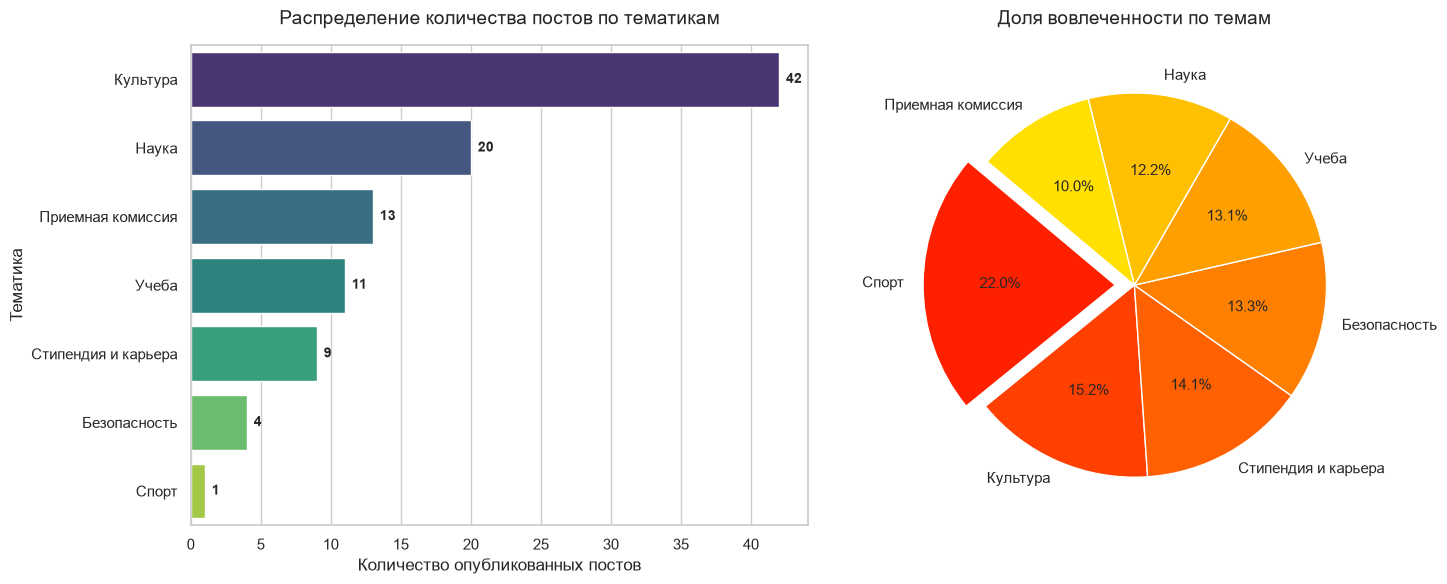

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля и поддержка русского языка в графиках
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.figsize"] = (15, 6)

fig, (ax1, ax2) = plt.subplots(1, 2)

# =========================================================================
# 1. ГРАФИК
# =========================================================================
topic_counts = df["topic"].value_counts()

sns.barplot(
    x=topic_counts.values,
    y=topic_counts.index,
    ax=ax1,
    palette="viridis",
    hue=topic_counts.index,
    legend=False,
)

ax1.set_title("Распределение количества постов по тематикам", fontsize=14, pad=15)
ax1.set_xlabel("Количество опубликованных постов", fontsize=12)
ax1.set_ylabel("Тематика", fontsize=12)

for i, v in enumerate(topic_counts.values):
    ax1.text(v + 0.5, i, str(v), va="center", fontsize=10, fontweight="bold")

# =========================================================================
# 2. ГРАФИК
# =========================================================================
# среднее арифметическое просмотров для каждой темы
topic_er = df.groupby("topic")["er"].mean().sort_values(ascending=False)

explode = [0.1 if i == 0 else 0 for i in range(len(topic_er))]

ax2.pie(
    topic_er.values,
    labels=topic_er.index,
    autopct="%1.1f%%",
    startangle=140,
    explode=explode,
    colors=sns.color_palette("autumn", len(topic_er)),
    textprops={"fontsize": 11},
)

ax2.set_title(
    "Доля вовлеченности по темам",
    fontsize=14,
    pad=15,
)

# Вывод графиков
plt.tight_layout()
plt.show()

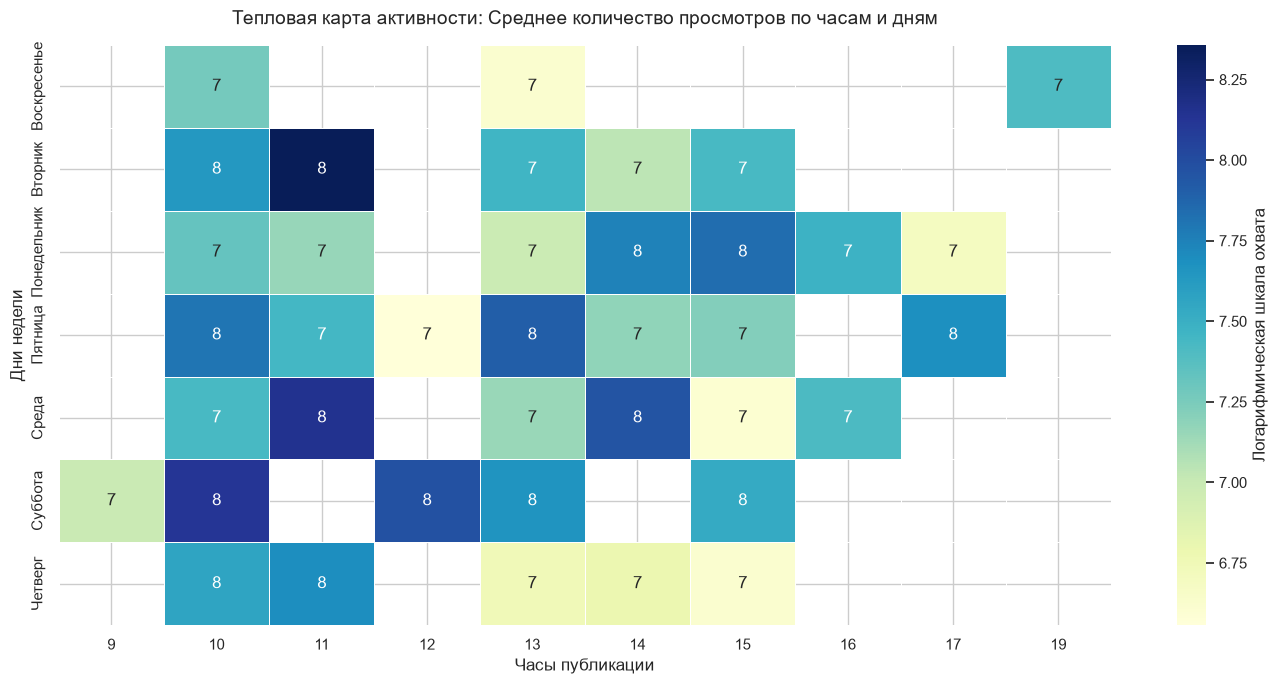

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


pivot_df = df.pivot_table(
    index='day', 
    columns='hour', 
    values='views',      # Колонка с просмотрами
    aggfunc='mean'       # Среднее количество просмотров
).fillna(0)

# 1. Готовим логарифмические данные
log_pivot = np.log1p(pivot_df)

# 2. Создаем маску: True там, где в исходной таблице были нули (нет постов)
# Такие ячейки вообще не будут закрашиваться
mask = (pivot_df == 0)

plt.figure(figsize=(14, 7))

# 3. Строим хитмап с маской
sns.heatmap(
    log_pivot,
    mask=mask,          # Скрывает пустые ячейки (они станут фонового цвета)
    cmap='YlGnBu',      # Вернем приятную глазу сине-желтую палитру
    annot=True,     # Оставляем реальные цифры просмотров
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Логарифмическая шкала охвата'} # Подпись к шкале
)

plt.title('Тепловая карта активности: Среднее количество просмотров по часам и дням', fontsize=14, pad=15)
plt.xlabel('Часы публикации', fontsize=12)
plt.ylabel('Дни недели', fontsize=12)

plt.tight_layout()
plt.show()
